In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# better visuals
sns.set_style("whitegrid")
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


In [ ]:
df = pd.read_csv("train.csv")  # change name
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


df = df.dropna()  # simple method for now

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [11]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

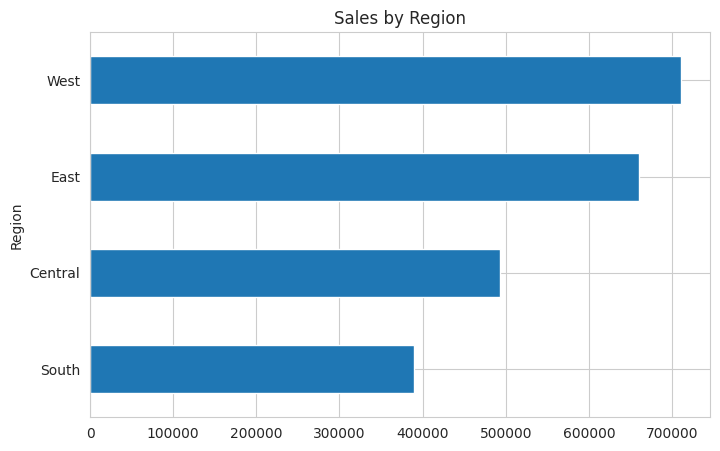

In [12]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

region_sales.plot(kind='barh', figsize=(8,5))
plt.title("Sales by Region")
plt.show()

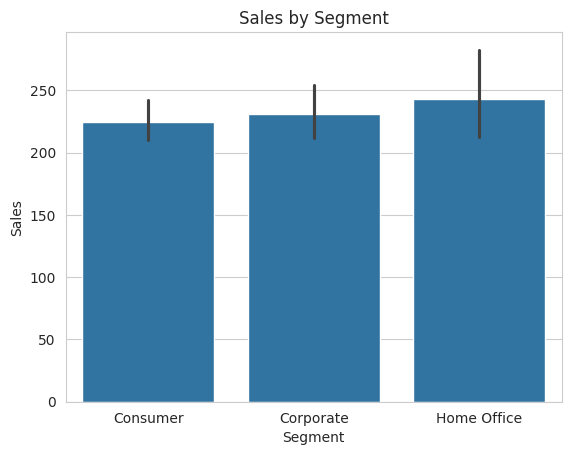

In [13]:
sns.barplot(x='Segment', y='Sales', data=df)
plt.title("Sales by Segment")
plt.show()

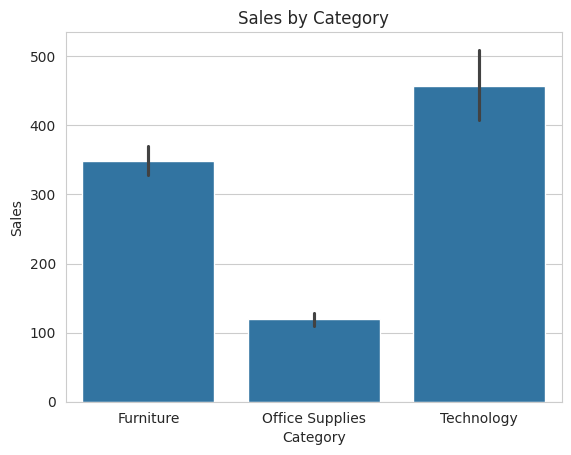

In [14]:
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

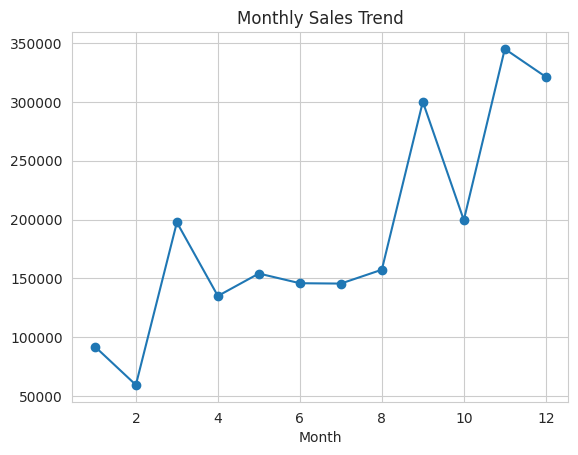

In [15]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.show()

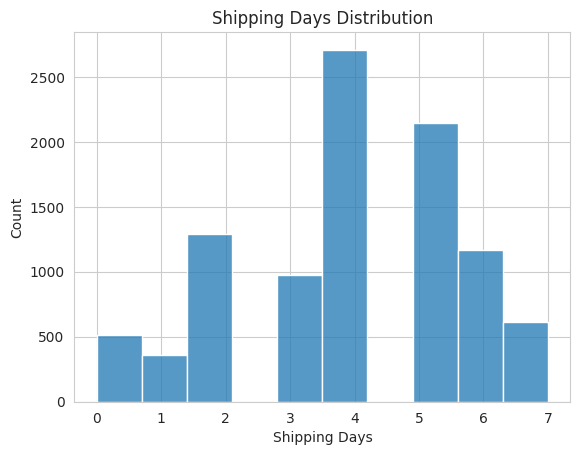

In [17]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

sns.histplot(df['Shipping Days'], bins=10)
plt.title("Shipping Days Distribution")
plt.show()